##Load Dataset

In [1]:
import pandas as pd
url = "https://raw.githubusercontent.com/johanliman/machineLearning/main/OAS_-_Live_Release_Rate.csv"
df = pd.read_csv(url)
df.head()

,Animal identification number,Impound type,Intake subcategory,Impound date and time,Animal intake condition,Outcome type,Outcome subtype,Departure date and time,Animal type
0,A510193,OWNER SUR,OTC OWNED,09/13/2023 12:20:00 PM,NORMAL,FOSTER,TO ADOPT,09/25/2023 05:15:00 PM,CAT
1,A536618,OWNER SUR,OTC OWNED,10/16/2025 11:04:00 AM,NORMAL,ADOPTION,LOCAL,10/24/2025 01:38:00 PM,CAT
2,A536276,STRAY,OTC,10/06/2025 12:17:00 PM,NORMAL,ADOPTION,OTHER,10/25/2025 01:59:00 PM,CAT
3,A440973,STRAY,OTC,07/28/2018 11:51:00 AM,ILL SEVERE,EUTH,ILL SEVERE,07/28/2018 01:03:00 PM,CAT
4,A518782,OWNER SUR,OTC OWNED,05/07/2024 11:32:00 AM,NORMAL,TRANSFER,RESCUE GRP,05/17/2024 11:30:00 AM,CAT


##Show missing informations

In [2]:
print(df.shape)
df.isnull().sum()

(41319, 9)


,0
Animal identification number,0
Impound type,0
Intake subcategory,0
Impound date and time,0
Animal intake condition,0
Outcome type,0
Outcome subtype,1265
Departure date and time,235
Animal type,0


##Data cleaning (remove missing data and duplicates)
##Convert date and time to days

In [3]:

df.dropna(how='all', inplace=True)
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna("Unknown")
df.drop_duplicates(inplace=True)


df['Impound date and time'] = pd.to_datetime(df['Impound date and time'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['Departure date and time'] = pd.to_datetime(df['Departure date and time'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

df['Length'] = (
    df['Departure date and time'] - df['Impound date and time']
).dt.days
df['Month'] = df['Impound date and time'].dt.month
df['Year'] = df['Impound date and time'].dt.year
df['DayOfWeek'] = df['Impound date and time'].dt.day_name()
df = df[df['Length'] >= 0]


df.head()



,Animal identification number,Impound type,Intake subcategory,Impound date and time,Animal intake condition,Outcome type,Outcome subtype,Departure date and time,Animal type,Length,Month,Year,DayOfWeek
0,A510193,OWNER SUR,OTC OWNED,2023-09-13 12:20:00,NORMAL,FOSTER,TO ADOPT,2023-09-25 17:15:00,CAT,12.0,9,2023,Wednesday
1,A536618,OWNER SUR,OTC OWNED,2025-10-16 11:04:00,NORMAL,ADOPTION,LOCAL,2025-10-24 13:38:00,CAT,8.0,10,2025,Thursday
2,A536276,STRAY,OTC,2025-10-06 12:17:00,NORMAL,ADOPTION,OTHER,2025-10-25 13:59:00,CAT,19.0,10,2025,Monday
3,A440973,STRAY,OTC,2018-07-28 11:51:00,ILL SEVERE,EUTH,ILL SEVERE,2018-07-28 13:03:00,CAT,0.0,7,2018,Saturday
4,A518782,OWNER SUR,OTC OWNED,2024-05-07 11:32:00,NORMAL,TRANSFER,RESCUE GRP,2024-05-17 11:30:00,CAT,9.0,5,2024,Tuesday


##Plot every features

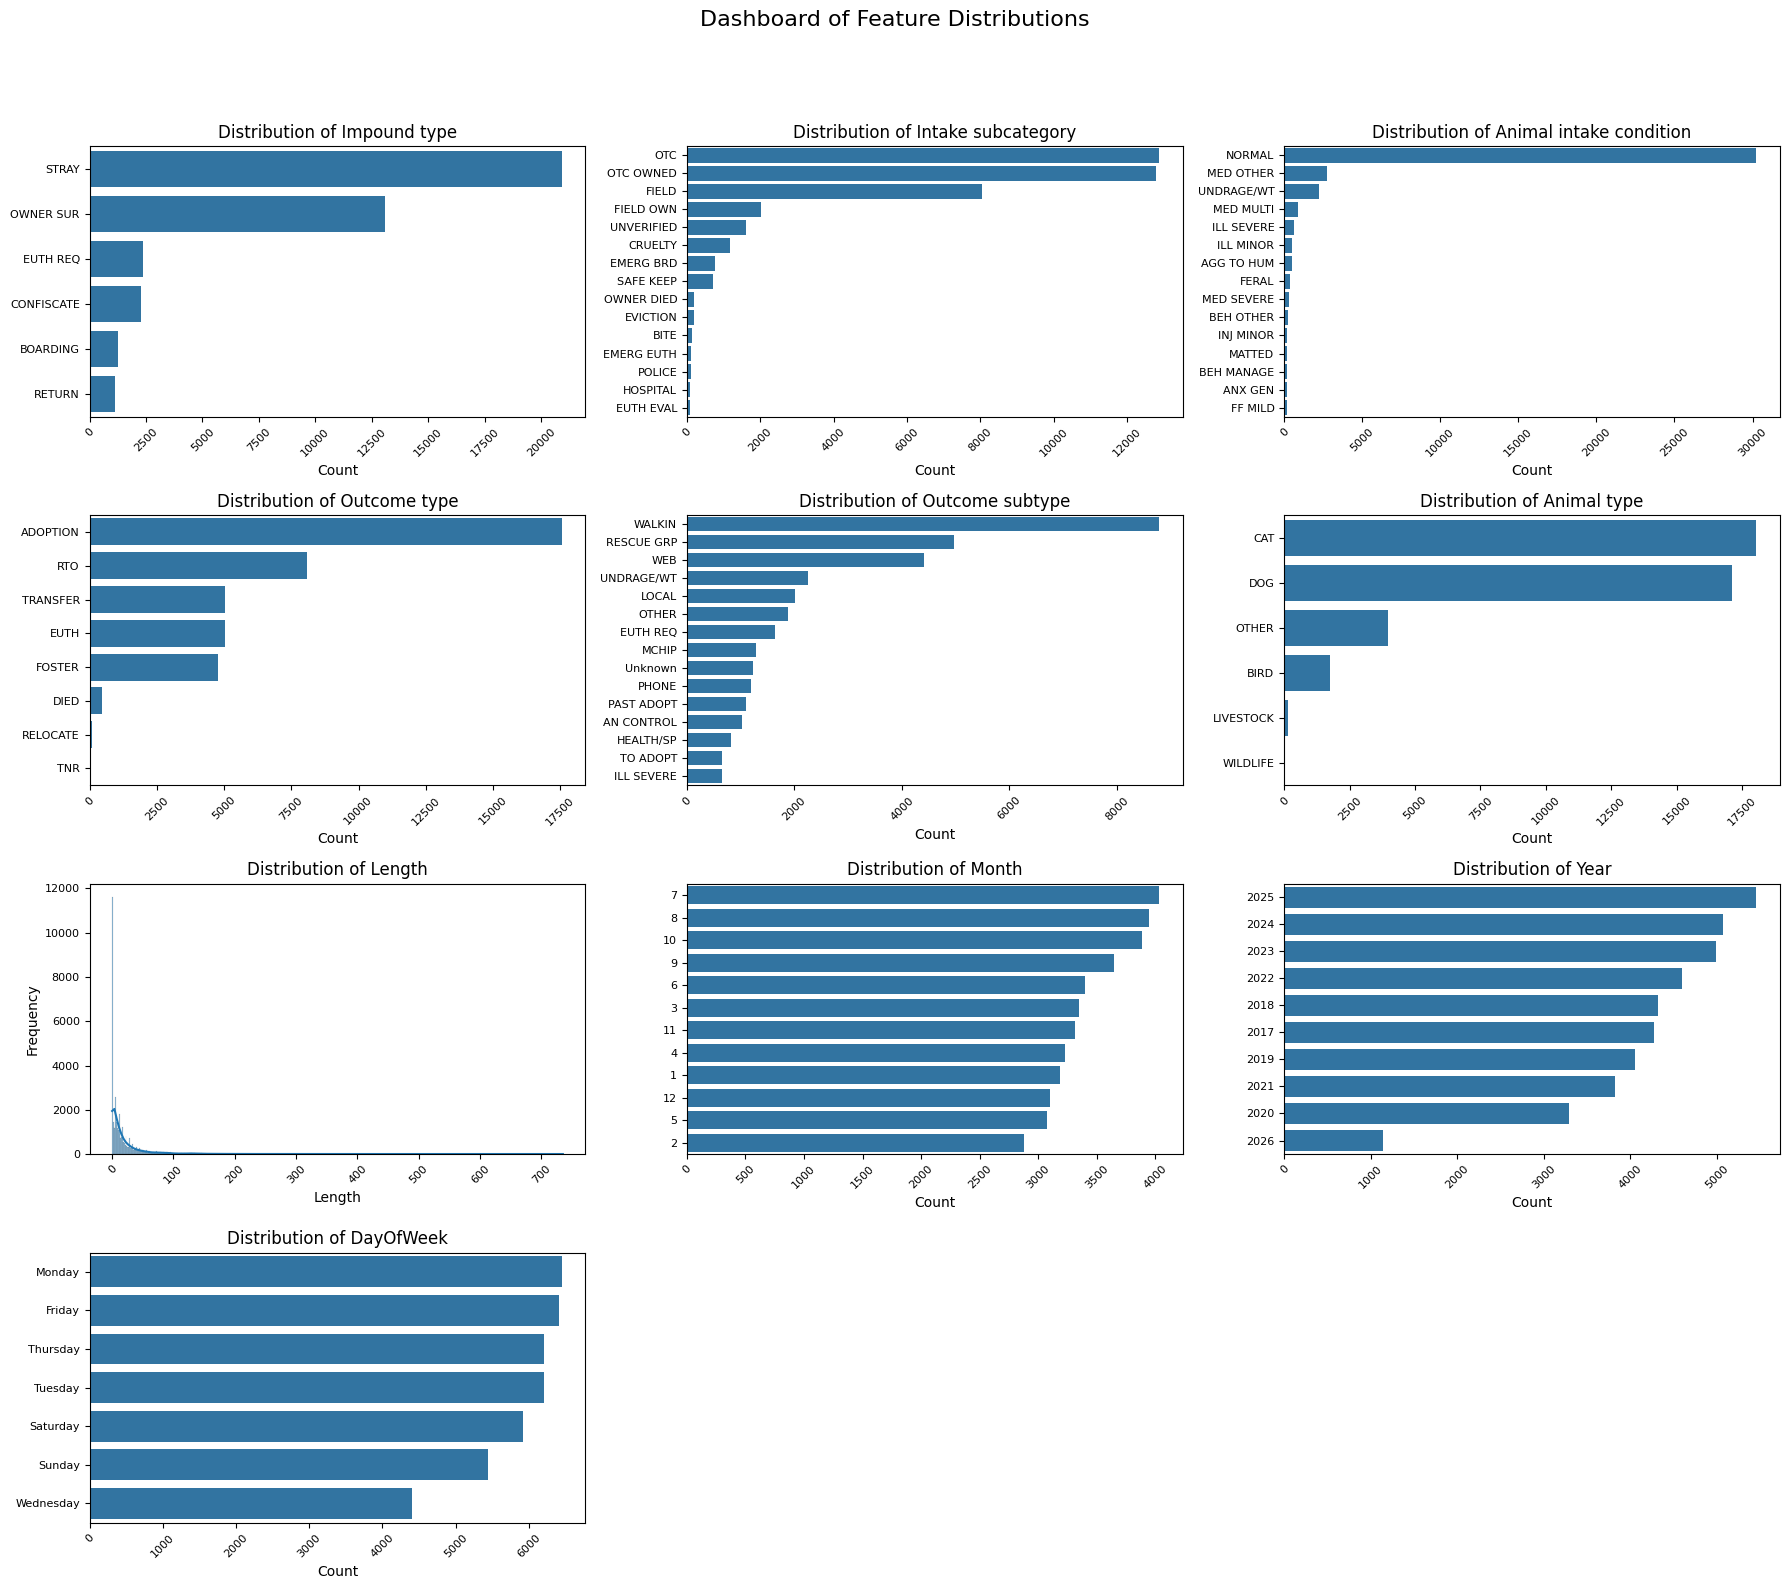

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

columns_to_plot = [
    'Impound type', 'Intake subcategory', 'Animal intake condition',
    'Outcome type', 'Outcome subtype', 'Animal type', 'Length',
    'Month', 'Year', 'DayOfWeek'
]

n_cols = 3
n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, col in enumerate(columns_to_plot):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    if df[col].dtype == 'object' or isinstance(df[col].dtype, pd.CategoricalDtype) or df[col].nunique() < 50:

        if df[col].nunique() > 15 and (df[col].dtype == 'object' or isinstance(df[col].dtype, pd.CategoricalDtype)):
            top_categories = df[col].value_counts().nlargest(15).index
            sns.countplot(y=col, data=df[df[col].isin(top_categories)], order=top_categories, ax=ax)
        else:
            sns.countplot(y=col, data=df, order=df[col].value_counts().index, ax=ax)

        ax.set_title(f'Distribution of {col}', fontsize=12)
        ax.set_ylabel('', fontsize=10)
        ax.set_xlabel('Count', fontsize=10)
    else:
        sns.histplot(df[col], kde=True, ax=ax)
        ax.set_title(f'Distribution of {col}', fontsize=12)
        ax.set_xlabel(col, fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)

    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Dashboard of Feature Distributions', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

##Count total alive and not alive

In [5]:
df.columns
outcome_col = "Outcome type"

df = df.dropna(subset=[outcome_col, "Impound date and time", "Departure date and time", "Length"]).copy()
live_labels = {"Adoption", "Transfer", "Return to Owner","RTO", "Rescue", "Foster", "RELOCATE", "TNR"}
df["alive"] = df[outcome_col].str.lower().isin([label.lower() for label in live_labels]).astype(int)
df["outcome_mc"] = df[outcome_col].astype(str)
outcome_counts = (df[["alive", "outcome_mc"]].value_counts().head(20).reset_index(name="count"))

print("Top Outcome Counts:")
print(outcome_counts.to_string(index=False))
alive_totals = (df["alive"].value_counts().reset_index(name="count"))
alive_totals.columns = ["alive", "count"]

print("\nTotals for alive status:")
print(alive_totals.to_string(index=False))

average_length = df["Length"].mean()
print(f"\nAverage length of all data: {average_length:.2f} days")

Top Outcome Counts:
 alive outcome_mc  count
     1   ADOPTION  17556
     1        RTO   8066
     1   TRANSFER   5026
     0       EUTH   5018
     1     FOSTER   4774
     0       DIED    479
     1   RELOCATE    105
     1        TNR     13

Totals for alive status:
 alive  count
     1  35540
     0   5497

Average length of all data: 19.48 days


In [6]:

non_alive_df = df[df["outcome_mc"].isin(["EUTH", "DIED"])].copy()
non_alive_stats = (non_alive_df.groupby("outcome_mc")["Length"].agg(shortest="min", longest="max", mean_avg="mean").reset_index())
non_alive_stats["mean_avg"] = non_alive_stats["mean_avg"].round(2)
print("\nNON-ALIVE")
print(non_alive_stats.to_string(index=False))


alive_df = df[~df["outcome_mc"].isin(["EUTH", "DIED"])].copy()
alive_stats = (alive_df.groupby("outcome_mc")["Length"].agg(shortest="min", longest="max", mean_avg="mean").reset_index())
alive_stats["mean_avg"] = alive_stats["mean_avg"].round(2)
print("\nALIVE / SURVIVAL OUTCOMES")
print(alive_stats.to_string(index=False))


NON-ALIVE
outcome_mc  shortest  longest  mean_avg
      DIED       0.0    293.0     12.22
      EUTH       0.0    560.0     12.73

ALIVE / SURVIVAL OUTCOMES
outcome_mc  shortest  longest  mean_avg
  ADOPTION       0.0    514.0     28.13
    FOSTER       0.0    613.0     15.83
  RELOCATE       0.0    129.0     29.16
       RTO       0.0    285.0      3.84
       TNR       8.0     40.0     16.62
  TRANSFER       0.0    735.0     25.08


BEFORE IQR
Total Rows: 41037
Max Length: 735.0 days

IQR STATS
Q1 (25th Percentile): 1.0 days
Q3 (75th Percentile): 22.0 days
IQR: 21.0 days
Calculated Upper Bound Cutoff: 53.5 days

FTER IQR
Total Rows Kept: 37226
Max Length Kept: 53.0 days


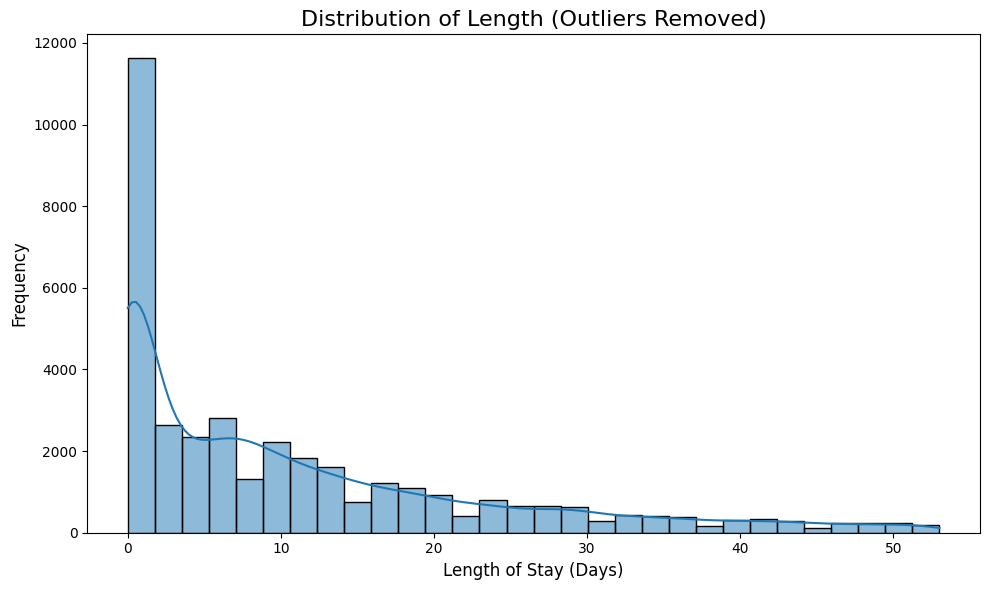

In [7]:
print("BEFORE IQR")
print(f"Total Rows: {len(df)}")
print(f"Max Length: {df['Length'].max()} days")

Q1 = df['Length'].quantile(0.25)
Q3 = df['Length'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print("\nIQR STATS")
print(f"Q1 (25th Percentile): {Q1} days")
print(f"Q3 (75th Percentile): {Q3} days")
print(f"IQR: {IQR} days")
print(f"Calculated Upper Bound Cutoff: {upper_bound} days")

df_clean = df[df['Length'] <= upper_bound]
print("\nFTER IQR")
print(f"Total Rows Kept: {len(df_clean)}")
print(f"Max Length Kept: {df_clean['Length'].max()} days")


plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Length'], kde=True, bins=30)
plt.title('Distribution of Length (Outliers Removed)', fontsize=16)
plt.xlabel('Length of Stay (Days)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tick_params(axis='x', rotation=0, labelsize=10)
plt.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()

##Receiver Operating Characteristic (ROC)

* 1.00 (100%) = Perfect model
* 0.90+ = Excellent
* 0.80+ = Good
* 0.70+ = Fair
* 0.50 (50%) = Random guessing
* <0.50 = Worse than random

ROC AUC: 0.5845323393394243
ROC AUC (%): 58.45%

Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.54      0.26      1099
           1       0.89      0.59      0.71      7109

    accuracy                           0.58      8208
   macro avg       0.53      0.57      0.48      8208
weighted avg       0.80      0.58      0.65      8208



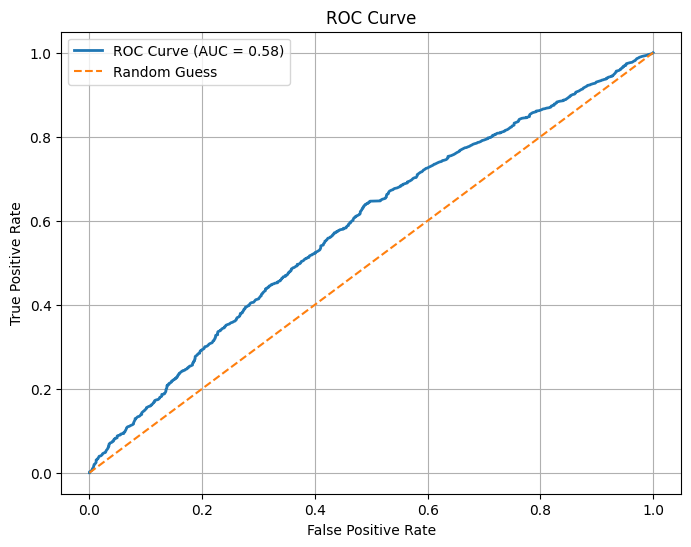

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    roc_curve
)
from sklearn.linear_model import LogisticRegression

X_cols = ['Month', 'Year', 'DayOfWeek']
X = df[X_cols].copy()
y = df["alive"].copy()

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X_cols if c not in cat_cols]


preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)


clf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
roc = roc_auc_score(y_test, proba)

print("ROC AUC:", roc)
print("ROC AUC (%): {:.2f}%".format(roc * 100))
print("\nClassification Report:")
print(classification_report(y_test, pred))

fpr, tpr, thresholds = roc_curve(y_test, proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, linewidth=2, label="ROC Curve (AUC = {:.2f})".format(roc))
plt.plot([0,1], [0,1], linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

Add Features


ROC AUC: 0.8577247874671164
ROC AUC (%): 85.77%

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.62      0.62      1099
           1       0.94      0.94      0.94      7109

    accuracy                           0.90      8208
   macro avg       0.78      0.78      0.78      8208
weighted avg       0.90      0.90      0.90      8208



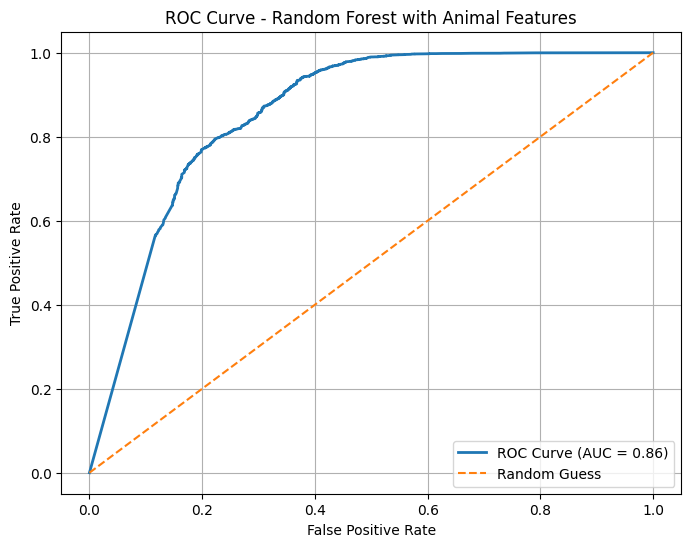

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    roc_curve
)
from sklearn.ensemble import RandomForestClassifier

X_cols = ['Month', 'Year', 'DayOfWeek','Animal type','Animal intake condition','Impound type','Intake subcategory']

X = df[X_cols].copy()
y = df["alive"].copy()

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X_cols if c not in cat_cols]


preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

clf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
roc = roc_auc_score(y_test, proba)


print("ROC AUC:", roc)
print("ROC AUC (%): {:.2f}%".format(roc * 100))
print("\nClassification Report:")
print(classification_report(y_test, pred))
fpr, tpr, thresholds = roc_curve(y_test, proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, linewidth=2, label="ROC Curve (AUC = {:.2f})".format(roc))
plt.plot([0,1], [0,1], linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest with Animal Features")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

ROC AUC: 0.8811
ROC AUC (%): 88.11%

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.66      0.66      1099
           1       0.95      0.95      0.95      7109

    accuracy                           0.91      8208
   macro avg       0.80      0.81      0.80      8208
weighted avg       0.91      0.91      0.91      8208



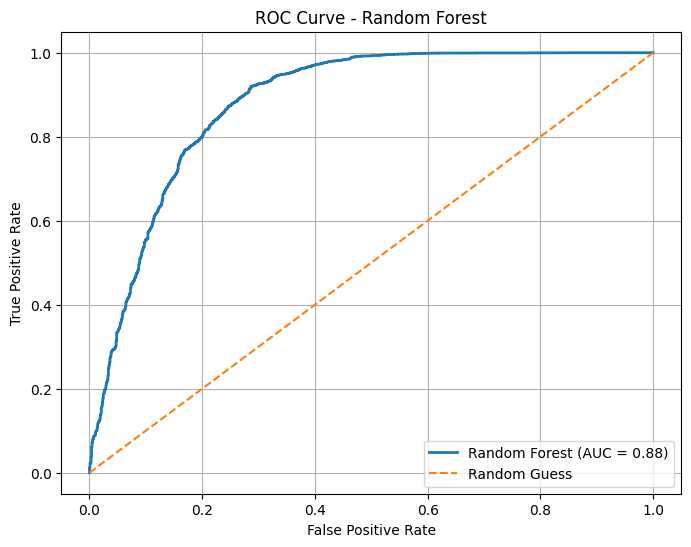

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    roc_curve
)
from sklearn.ensemble import RandomForestClassifier

X_cols = [
    'Month', 'Year', 'DayOfWeek',
    'Animal type',
    'Animal intake condition',
    'Impound type',
    'Intake subcategory'
]

X = df[X_cols].copy()
y = df["alive"].copy()

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X_cols if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

clf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
roc = roc_auc_score(y_test, proba)

print(f"ROC AUC: {roc:.4f}")
print(f"ROC AUC (%): {roc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, pred))

fpr, tpr, thresholds = roc_curve(y_test, proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, linewidth=2, label=f"Random Forest (AUC = {roc:.2f})")
plt.plot([0,1], [0,1], linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

##Regression model : Predict number of days animal stays in shelter.

In [11]:
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

#X = df_clean[X_cols].copy()
#y = np.log1p(df_clean["Length"].clip(lower=0))

X = df[X_cols].copy()
y = np.log1p(df["Length"].clip(lower=0))

reg = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg.fit(X_train, y_train)

pred_log = reg.predict(X_test)
pred_days = np.expm1(pred_log)
true_days = np.expm1(y_test)

print(f"MAE: {mean_absolute_error(true_days, pred_days):.2f} days")

MAE: 14.61 days


In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

df_filtered = df[df["Length"] <= 53].copy()

print(f"Rows number including outliers: {len(df)}")
print(f"Rows number after removing outliers: {len(df_filtered)}")
print(f"New Average Length: {df_filtered['Length'].mean():.2f} days\n")

X = df_filtered[X_cols].copy()

y = np.log1p(df_filtered["Length"].clip(lower=0))


cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X_cols if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

reg = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

reg.fit(X_train, y_train)

pred_log = reg.predict(X_test)


pred_days = np.expm1(pred_log)
true_days = np.expm1(y_test)

new_mae = mean_absolute_error(true_days, pred_days)

print(f"New MAE: {new_mae:.2f} days")

Rows number including outliers: 41037
Rows number after removing outliers: 37226
New Average Length: 11.06 days

New MAE: 7.64 days


##Multi-Class Classification
Predict exact outcome:
* Adoption
* Transfer
* Euthanasia
* Return to Owner

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

target_outcomes = ['ADOPTION', 'TRANSFER', 'EUTH', 'RTO']
df_filtered = df[df['outcome_mc'].isin(target_outcomes)].copy()

X_cols = [
    'Month', 'Year', 'DayOfWeek',
    'Animal type',
    'Animal intake condition',
    'Impound type',
    'Intake subcategory'
]

X = df_filtered[X_cols].copy()
y = df_filtered["outcome_mc"].copy()

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X_cols if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

mc = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

mc.fit(X_train, y_train)
pred = mc.predict(X_test)

print(f"\nAccuracy: {accuracy_score(y_test, pred):.2%}")
print(classification_report(y_test, pred, zero_division=0))


Accuracy: 68.36%
              precision    recall  f1-score   support

    ADOPTION       0.78      0.66      0.72      3512
        EUTH       0.70      0.69      0.69      1004
         RTO       0.65      0.85      0.74      1613
    TRANSFER       0.46      0.50      0.48      1005

    accuracy                           0.68      7134
   macro avg       0.65      0.67      0.66      7134
weighted avg       0.70      0.68      0.68      7134



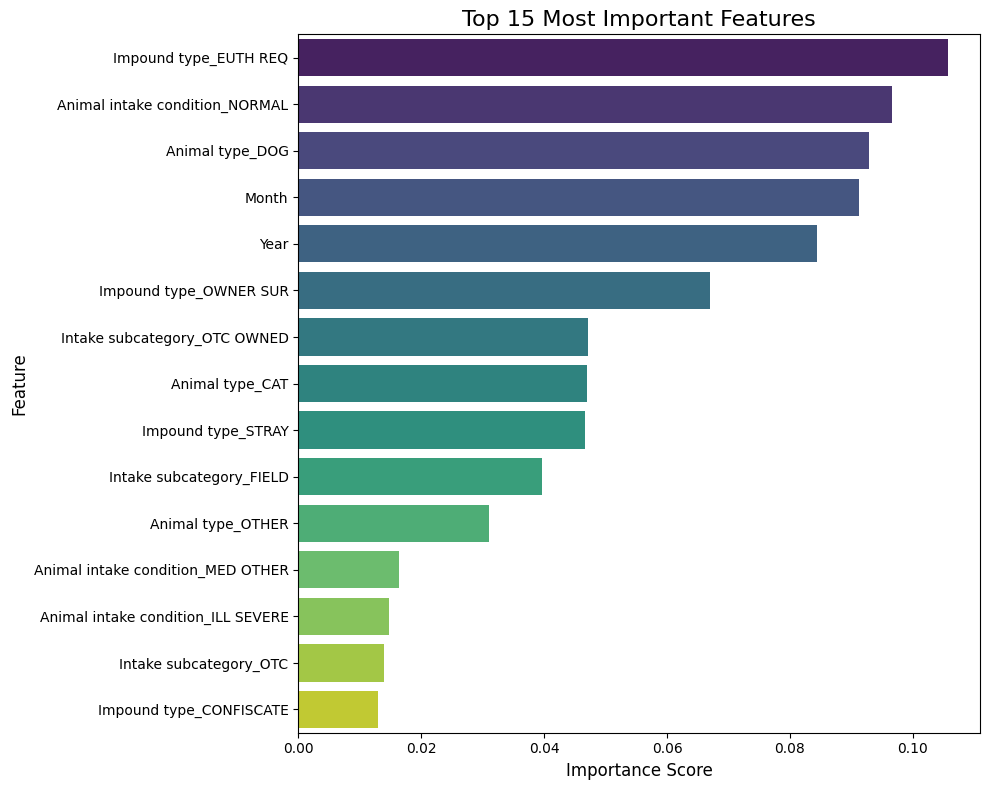

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rf_model = mc.named_steps['model']


feature_names = mc.named_steps['prep'].get_feature_names_out()

clean_names = [name.split("__")[-1] for name in feature_names]

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': clean_names,
    'Importance': importances
})


importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(15),
    palette='viridis',
    hue='Feature',
    legend=False
)

plt.title('Top 15 Most Important Features', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

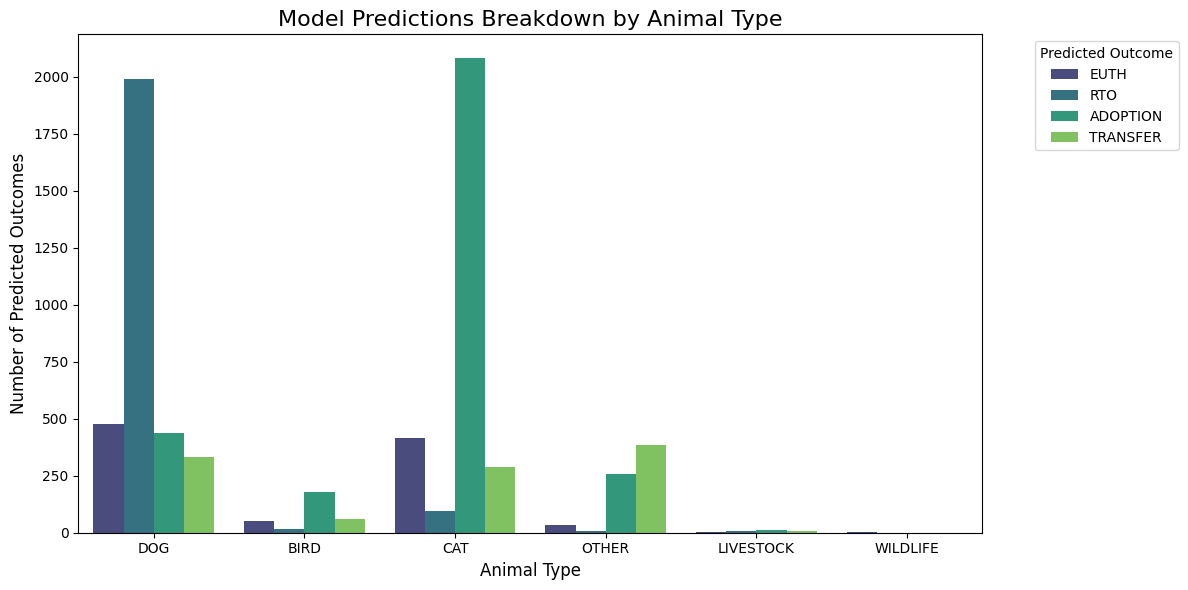

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

results_df = pd.DataFrame({
    'Animal Type': X_test['Animal type'],
    'Predicted Outcome': pred
})


plt.figure(figsize=(12, 6))

sns.countplot(
    data=results_df,
    x='Animal Type',
    hue='Predicted Outcome',
    palette='viridis'
)

plt.title('Model Predictions Breakdown by Animal Type', fontsize=16)
plt.xlabel('Animal Type', fontsize=12)
plt.ylabel('Number of Predicted Outcomes', fontsize=12)
plt.legend(title='Predicted Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


TOP 20 HIGH RISK ANIMALS:
       Month  Year  DayOfWeek Animal type Animal intake condition  \
2172       7  2017     Friday         DOG              ILL SEVERE   
37358      8  2018     Friday         DOG              ILL SEVERE   
22518      2  2017     Friday         DOG              ILL SEVERE   
8359       3  2017     Friday         DOG              ILL SEVERE   
35448      1  2017     Friday         DOG              ILL SEVERE   
28545      1  2017     Friday         DOG              ILL SEVERE   
20750      2  2018     Friday         DOG              ILL SEVERE   
27590      2  2018     Friday         DOG              ILL SEVERE   
4633       6  2018     Friday         DOG              ILL SEVERE   
24253     10  2018     Friday         DOG              ILL SEVERE   
13711      1  2018     Friday         DOG              ILL SEVERE   
20375      5  2018     Friday         DOG              ILL SEVERE   
22538     11  2018     Friday         DOG              ILL SEVERE   
24602  

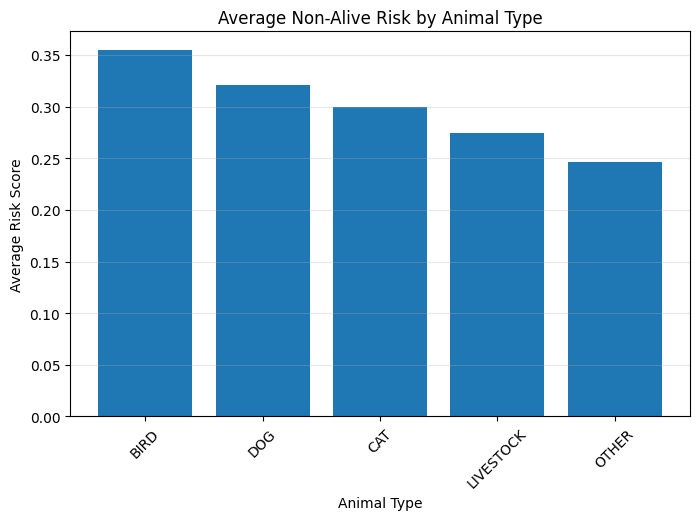


NON-ALIVE REASON DISTRIBUTION BY ANIMAL TYPE (%):
outcome_mc        DIED       EUTH
Animal type                      
DOG           1.420030  98.579970
CAT          11.562351  88.437649
BIRD         17.948718  82.051282
WILDLIFE     33.333333  66.666667
LIVESTOCK    50.000000  50.000000
OTHER        35.792350  64.207650


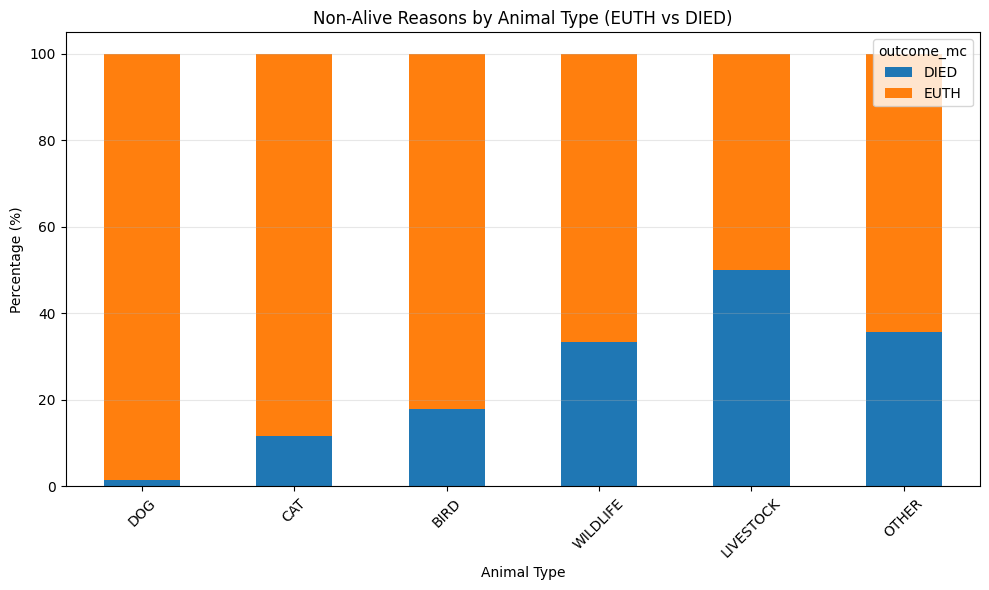


NON-ALIVE PERCENTAGE BY ANIMAL TYPE:
Animal type
DOG          15.622628
CAT          11.600709
BIRD         19.988610
WILDLIFE     60.000000
LIVESTOCK     5.194805
OTHER         9.263478
Name: outcome_mc, dtype: float64


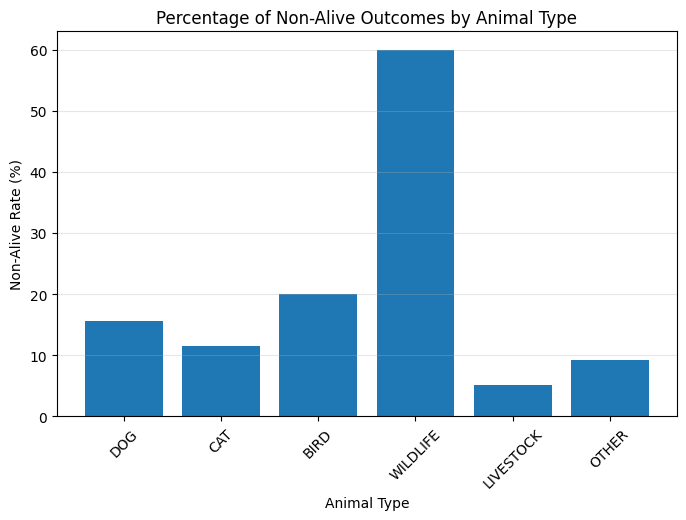

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier


df_risk = df.copy()
df_risk["non_alive_risk"] = df_risk["outcome_mc"].isin(["EUTH", "DIED"]).astype(int)

X_cols = [
    "Month", "Year", "DayOfWeek",
    "Animal type",
    "Animal intake condition",
    "Impound type",
    "Intake subcategory"
]

X = df_risk[X_cols]
y = df_risk["non_alive_risk"]

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X_cols if c not in cat_cols]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)

risk_scores = model.predict_proba(X_test)[:, 1]

results = X_test.copy()
results["risk_score"] = risk_scores
results["actual_non_alive"] = y_test.values


top20 = results.sort_values("risk_score", ascending=False).head(20)

print("\nTOP 20 HIGH RISK ANIMALS:")
print(top20)

animal_risk = results.groupby("Animal type").agg(
    avg_risk=("risk_score", "mean"),
    total_animals=("risk_score", "count"),
    actual_non_alive_rate=("actual_non_alive", "mean")
).sort_values("avg_risk", ascending=False)

print("\nRISK SUMMARY BY ANIMAL TYPE:")
print(animal_risk)


plt.figure(figsize=(8, 5))
plt.bar(animal_risk.index, animal_risk["avg_risk"])
plt.title("Average Non-Alive Risk by Animal Type")
plt.xlabel("Animal Type")
plt.ylabel("Average Risk Score")
plt.xticks(rotation=45)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

animal_order = ["DOG", "CAT", "BIRD", "WILDLIFE", "LIVESTOCK", "OTHER"]

non_alive_df = df[df["outcome_mc"].isin(["EUTH", "DIED"])].copy()

reason_by_type = pd.crosstab(
    non_alive_df["Animal type"],
    non_alive_df["outcome_mc"],
    normalize="index"
).reindex(animal_order) * 100

print("\nNON-ALIVE REASON DISTRIBUTION BY ANIMAL TYPE (%):")
print(reason_by_type)


reason_by_type.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Non-Alive Reasons by Animal Type (EUTH vs DIED)")
plt.ylabel("Percentage (%)")
plt.xlabel("Animal Type")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


animal_non_alive_pct = (
    df.groupby("Animal type")["outcome_mc"]
    .apply(lambda x: x.isin(["EUTH", "DIED"]).mean() * 100)
    .reindex(animal_order)
)

print("\nNON-ALIVE PERCENTAGE BY ANIMAL TYPE:")
print(animal_non_alive_pct)


plt.figure(figsize=(8, 5))
plt.bar(animal_non_alive_pct.index, animal_non_alive_pct.values)

plt.title("Percentage of Non-Alive Outcomes by Animal Type")
plt.xlabel("Animal Type")
plt.ylabel("Non-Alive Rate (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

##Time Series Forecasting : Forecast future monthly live release rate.

                       live_release_rate  live_release_rate_pct  rolling_6m
Impound date and time                                                      
2017-01-01                      0.856631              85.663082         NaN
2017-02-01                      0.787546              78.754579         NaN
2017-03-01                      0.874608              87.460815         NaN
2017-04-01                      0.860627              86.062718         NaN
2017-05-01                      0.825485              82.548476         NaN
2017-06-01                      0.840749              84.074941   84.094102
2017-07-01                      0.819797              81.979695   83.480204
2017-08-01                      0.837416              83.741648   84.311382
2017-09-01                      0.896641              89.664083   84.678594
2017-10-01                      0.850220              85.022026   84.505145
2017-11-01                      0.893939              89.393939   85.646056
2017-12-01  

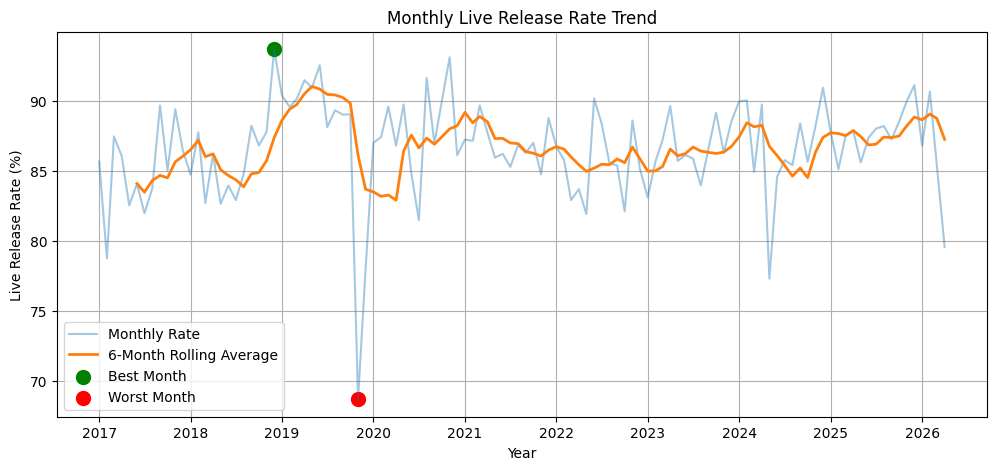

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

monthly = (
    df.set_index("Impound date and time")
      .resample("MS")["alive"]
      .mean()
      .rename("live_release_rate")
      .to_frame()
)


monthly["live_release_rate_pct"] = monthly["live_release_rate"] * 100

monthly["rolling_6m"] = monthly["live_release_rate_pct"].rolling(6).mean()


pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)

print(monthly)
best_month = monthly["live_release_rate_pct"].idxmax()
worst_month = monthly["live_release_rate_pct"].idxmin()
best_value = monthly.loc[best_month, "live_release_rate_pct"]
worst_value = monthly.loc[worst_month, "live_release_rate_pct"]
print("\nBEST MONTH")
print(f"{best_month.date()} → {best_value:.2f}%")
print("\nWORST MONTH")
print(f"{worst_month.date()} → {worst_value:.2f}%")


plt.figure(figsize=(12, 5))
plt.plot(
    monthly.index,
    monthly["live_release_rate_pct"],
    alpha=0.4,
    label="Monthly Rate"
)

plt.plot(
    monthly.index,
    monthly["rolling_6m"],
    linewidth=2,
    label="6-Month Rolling Average"
)

plt.scatter(best_month, best_value, color="green", s=100, label="Best Month")
plt.scatter(worst_month, worst_value, color="red", s=100, label="Worst Month")

plt.title("Monthly Live Release Rate Trend")
plt.xlabel("Year")
plt.ylabel("Live Release Rate (%)")
plt.legend()
plt.grid(True)

plt.show()

pd.reset_option('display.max_rows')
pd.reset_option('display.width')

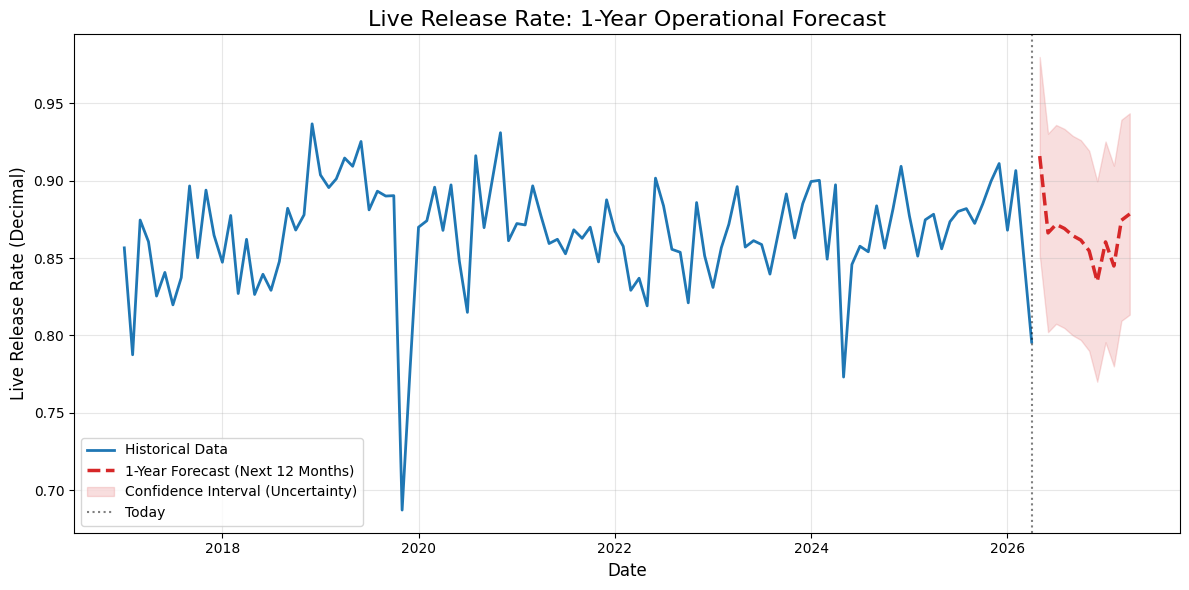

2026-05    91.59%
2026-06    86.63%
2026-07    87.18%
2026-08    86.92%
2026-09    86.45%
2026-10    86.17%
2026-11    85.47%
2026-12    83.49%
2027-01    86.05%
2027-02    84.49%
2027-03    87.44%
2027-04    87.85%


In [18]:
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

y_ts = monthly["live_release_rate"]

model_1yr = SARIMAX(
    y_ts,
    order=(1,0,1),
    seasonal_order=(1,0,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_1yr = model_1yr.fit(disp=False)

forecast_1yr = fit_1yr.get_forecast(steps=12)

pred_mean = forecast_1yr.predicted_mean
conf_int = forecast_1yr.conf_int()

plt.figure(figsize=(12, 6))

plt.plot(y_ts.index, y_ts, label='Historical Data', color='#1f77b4', linewidth=2)

plt.plot(pred_mean.index, pred_mean, label='1-Year Forecast (Next 12 Months)', color='#d62728', linestyle='--', linewidth=2.5)

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='#d62728',
    alpha=0.15,
    label='Confidence Interval (Uncertainty)'
)

plt.axvline(x=y_ts.index[-1], color='black', linestyle=':', alpha=0.5, label='Today')


plt.title('Live Release Rate: 1-Year Operational Forecast', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Live Release Rate (Decimal)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


for date, value in pred_mean.items():
    clean_date = date.strftime('%Y-%m')

    clean_value = f"{value * 100:.2f}%"

    print(f"{clean_date}    {clean_value}")